# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026, posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit, including a machine's, is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$, except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

naive fit: slope=1.97, +/-0.11, intercept=12.82, +/- intercept=0.67, 
chi2=728.41, chi2_red=26.01


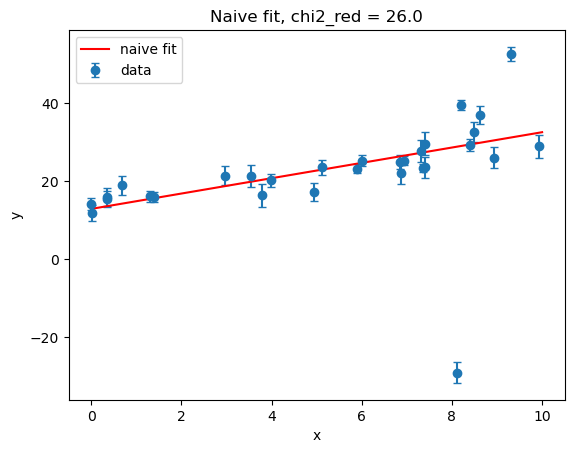

In [1]:
import numpy as np
import matplotlib.pyplot as plt

d = np.genfromtxt('data/jhaff2.csv', delimiter=',', names=True)
x,y, sigma_y = d['x'], d['y'], d['sigma_y']

p_naive, pcov = np.polyfit(x, y, 1, w=1/sigma_y, cov='unscaled')

slope_er = np.sqrt(pcov[0, 0])
inter_er = np.sqrt(pcov[1, 1])

resid = y - np.polyval(p_naive, x)
chi2 = np.sum((resid / sigma_y) ** 2)
chi2_red = chi2 / (len(x) - 2)
av = np.average(sigma_y)
print(f"naive fit: slope={p_naive[0]:.2f}, +/-{slope_er:.2f}, intercept={p_naive[1]:.2f}, +/- intercept={inter_er:.2f}, ")


print(f"chi2={chi2:.2f}, chi2_red={chi2_red:.2f}")

xx = np.linspace(0, 10, 200)
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label='naive fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Naive fit, chi2_red = {chi2_red:.1f}')
plt.show()

**ANSWER (a few sentences):**

Chi2_red is aboive 1, which is a strong waring sign things are not a good fit to the points. The error bars are too large and misleading as well, and the outside range points are shifting the average and error bars. 

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment; this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer**, one set of numbers
you'd put in a paper, and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

3-sigma clip: slope=1.57 +/-0.11, intercept=14.07+/-0.67  chi2_red=1.19, clipped 4 of 30 points
actually-contaminated indices: []; clipped indices: [np.int64(22), np.int64(23), np.int64(26), np.int64(28)]


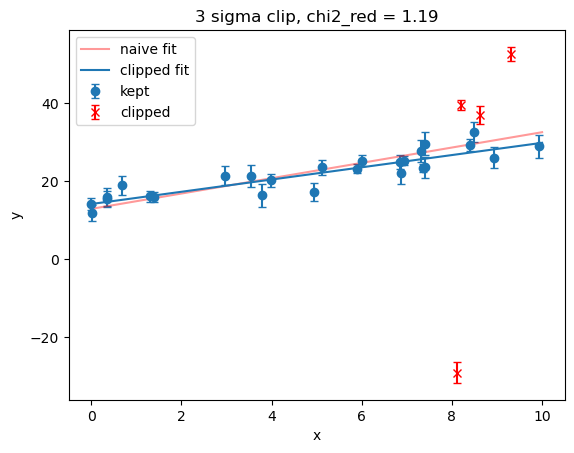

I choose 3 because its what looked like it matched the data the best as a starting rough guess, andwhen I programed a slider into it it was about my intuition


In [2]:
chosen_k = 3
def sigma_clip_fit(x, y, sigma, k, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, pcov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov='unscaled')
        resid = (y - np.polyval(p, x)) / sigma
        slope_er = np.sqrt(pcov[0, 0])
        inter_er = np.sqrt(pcov[1, 1])
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask
bad=[]
p_clip, mask = sigma_clip_fit(x, y, sigma_y, k=chosen_k)
resid = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid / sigma_y[mask]) ** 2) / (mask.sum() - 2)
print(f"3-sigma clip: slope={p_clip[0]:.2f} +/-{slope_er:.2f}, intercept={p_clip[1]:.2f}+/-{inter_er:.2f}  "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {len(x)} points")
print(f"actually-contaminated indices: {sorted(bad)}; clipped indices: {sorted(np.where(~mask)[0])}")

plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, color='C0', label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', alpha=0.4, label='naive fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0-', label='clipped fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'3 sigma clip, chi2_red = {chi2_red_clip:.2f}')
plt.show()
print("I choose 3 because its what looked like it matched the data the best as a starting rough guess, andwhen I programed a slider into it it was about my intuition")

mixture fit: slope=1.57 +/-0.11,  intercept=14.07 +/-0.67, outlier fraction Pb=0.16 (true fraction = 0.00)


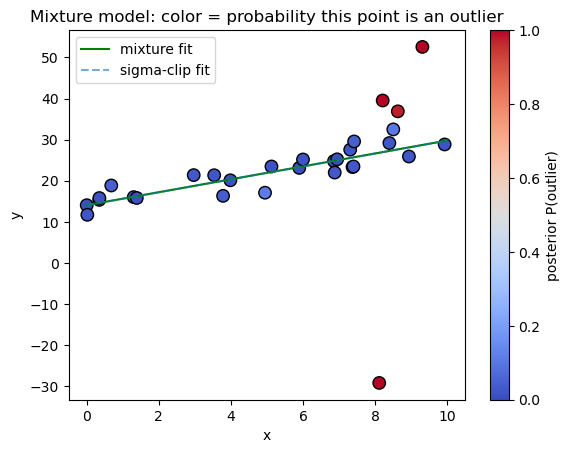

point-by-point P(outlier):
  point 23: P(outlier)=1.00  [clean]
  point 28: P(outlier)=1.00  [clean]
  point 22: P(outlier)=1.00  [clean]
  point 26: P(outlier)=0.97  [clean]
  point 11: P(outlier)=0.11  [clean]
  point 25: P(outlier)=0.10  [clean]


In [3]:
from scipy.optimize import minimize
from scipy.stats import norm
sigma = sigma_y 
def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))
n = len(x) 
theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
print(f"mixture fit: slope={m_mix:.2f} +/-{slope_er:.2f},  intercept={b_mix:.2f} +/-{inter_er:.2f}, "
      f"outlier fraction Pb={Pb_mix:.2f} (true fraction = {len(bad)/n:.2f})")

Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', alpha=0.6, label='sigma-clip fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('Mixture model: color = probability this point is an outlier')
plt.show()

print("point-by-point P(outlier):")
for i in np.argsort(-p_bad)[:6]:
    flag = 'REAL contaminant' if i in bad else 'clean'
    print(f"  point {i}: P(outlier)={p_bad[i]:.2f}  [{flag}]")

As per my mixed model which I trust more, I'd cut:
 point-by-point P(outlier):
  point 23: P(outlier)=1.00  [clean]
  point 28: P(outlier)=1.00  [clean]
  point 22: P(outlier)=1.00  [clean]
  point 26: P(outlier)=0.97  [clean]
  
As points to cut, leaving me with 26 data points left. These ones had values of 1 or 0.97, almost one, which I felt safe cutting after looking at it. 23, 28, 22, 26 all cut. I trust the mixed model a lot more because it tells me the statistics in a way where I can make the determinations myself when looking at the percentages, and, I don't have to randomly change one variable again and again to just see when it looks right. 

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong, in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* In step 1, it never uses the sigma_y values at all. It sets "cov" to true, when it's supposed to be w=1/sigma_y. Recreated below, it recreates exactly what the AI did by just changing that one part of my code at the start of the cade in the polyfit function. I simply removed the 4th term entirely though, and that replicated it. Correct treatment is to use sigma_y values and attach them into the polyfit function so it will run giving each point its proper error. 

*Flaw 2:* The Step 3 part gets a new chi2 value of 1.000, which already looks off compared to my data. When I took a closer look, it seems the function used goes to 1 by default since it all cancels out
chi2_new = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / (sigma_y * np.sqrt((chi2 / (mask.sum() - 2))[mask])**2) / (mask.sum() - 2)
^ Longer version, but noticiably some of the variables begin to cancel out. 
Explains why 1 value is obtained and why it seeminly fits the points better than it really does. I used the correct chi2 value equations in my code, spesifcally p_clip, mask = sigma_clip_fit(x, y, sigma_y, k=chosen_k)
resid = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid / sigma_y[mask]) ** 2) / (mask.sum() - 2)


*Flaw 3:* Step 2 has the same problemwith outlier removal as step 1, so the function never uses sigma y at all which explains why it only filtered one data point. You can see flaw 1 below again to get a similar sense at what it might look like, but essentially it assumes a fixed error rate. Including the sigma y fixes this.


It is trying to hide this from us because it displays no graphs which would show how crazy and incorrect the algorithm really is. 


FLAW 1
naive fit: slope=1.58, intercept=13.82


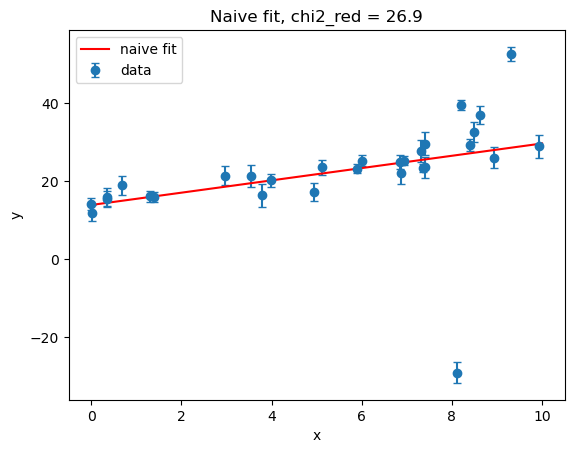

In [5]:
print("FLAW 1")
p_naive = np.polyfit(x, y, 1)
resid = y - np.polyval(p_naive, x)
chi2 = np.sum((resid / sigma_y) ** 2)
chi2_red = chi2 / (len(x) - 2)
av = np.average(sigma_y)
print(f"naive fit: slope={p_naive[0]:.2f}, intercept={p_naive[1]:.2f}")
xx = np.linspace(0, 10, 200)
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label='naive fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Naive fit, chi2_red = {chi2_red:.1f}')
plt.show()



## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

No AI used. Did google some stuff about the polyfit and cov variables to figure that out, though, and I had no idea how those functions worked.

**VERIFICATION PLAN:**

For a sanity check, I put a peice of paper over my computer and drew a trend line of what I thought it would look most like and confirmed it matched what I was actually getting. Failure here would've meant my line either was filtering too many or too little points out, compared to my intuition. When I ranboth parts of it, I wanted to ensure that they overall looked simialr and they did, including exclusing the same points. If they differed wildly from the naive model or from each other, I would have known something was wrong. They did converge though so I figured it was right. 